# vcgsuite in 60 Sekunden

Ein 10-Sekunden-EKG rein, eine 3D-Vektorkardiogramm-Geometrie raus: dieses Notebook zeigt in wenigen Zellen, wie `vcgsuite` aus rohen 12-Kanal-Daten automatisch Beats erkennt, P-/QRS-/T-Wellen annotiert und daraus eine 3D-Trajektorie samt Loop-Features baut.

**Daten:** ein Record aus der [LUDB](https://physionet.org/content/ludb/1.0.1/) (PhysioNet, Open Data Commons Attribution License v1.0) — 10 s, 12 Kanäle, 500 Hz, gesunde Sinusrhythmus-Aufnahme. Liegt fertig unter `../data/ludb_record_157/`, kein Download nötig.

> Zitierung: Kalyakulina et al., *LUDB: A New Open-Access Validation Tool for Electrocardiogram Delineation Algorithms*, IEEE Access, 2020.


In [1]:
import numpy as np
import pandas as pd
import wfdb

import vcgsuite as ecg
from vcgsuite.viz.r_peaks import plot_r_peak_detection
from vcgsuite.viz.vcg_annotated import build_plot_data, select_time_window, plot_signal_segments_and_markers, plot_vcg_3d
from vcgsuite.hrv.prep import build_rr_dataframe
from vcgsuite.hrv.helpers import compute_hrv_full
from vcgsuite.viz.hrv_dashboard import plot_kubios_ans_balance

# Plots bekommen zusätzlich ein PNG mitgeliefert (neben dem interaktiven
# Plotly-Output) — dadurch werden sie auch auf GitHub sichtbar, das
# Plotlys interaktives Format nicht rendert.
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+png"

print(f"vcgsuite {ecg.__version__}")


vcgsuite 0.1.0


## 1. Laden → Filtern → VCG-Transformation

In [2]:
LEAD_ORDER_8 = ["I", "II", "V1", "V2", "V3", "V4", "V5", "V6"]

rec = wfdb.rdrecord("../data/ludb_record_157/157")
fs = float(rec.fs)
lead_idx = {name: i for i, name in enumerate(rec.sig_name)}
ecg_raw = {lead: rec.p_signal[:, lead_idx[lead.lower()]] for lead in LEAD_ORDER_8}

filtered = ecg.filter_pipeline([ecg_raw[lead] for lead in LEAD_ORDER_8], fs=fs)
ecg_filt = {lead: filtered[i] for i, lead in enumerate(LEAD_ORDER_8)}

X, Y, Z = ecg.ecg12_to_frank_xyz(ecg_filt, method="IDT", lead_order=LEAD_ORDER_8)
t_ax = np.arange(rec.sig_len) / fs
df_analysis = pd.DataFrame({"Time": t_ax, "X": X, "Y": Y, "Z": Z, **ecg_filt})
df_analysis.attrs["fs"] = fs

df_analysis, dt = ecg.compute_vcg_kinematics(df_analysis)


Power of components removed by DSS: 0.00
ZapLine: 50.0 Hz, bis 5. Harmonische, nremove=1
FIR: HP 1.5 Hz (201 Taps)  →  LP 37.5 Hz (21 Taps)
✅ 12-Kanal → Frank XYZ  (Methode: IDT)


## 2. R-Peaks, Beat-Annotation

Eine Zeile pro Schritt: R-Peak-Erkennung, R-Turn (VCG-Kinematik), hierarchische Beat-Annotation (P-/QRS-/T-Marker).


In [3]:
r_peak_times, r_peak_values = ecg.detect_r_peaks(df_analysis)
r_turn_times, _ = ecg.detect_r_turn(df_analysis, r_peak_times)
df_annotations = ecg.annotate_all_beats(df_analysis, r_peak_times, r_turn_times)

print(f"{len(r_peak_times)} Beats erkannt, {fs:.0f} Hz, {rec.sig_len/fs:.1f} s Aufnahme")


Sampling-Rate:     500.0 Hz
Fensterbreite:     10.0 s  (4999 Samples)
Detektierte Peaks: 9
Ø RR-Abstand:      1084.5 ms
Ø HF:              55.3 bpm
RR-Bereich:        1016 – 1132 ms
R_turn gefunden:   9 / 9
Ø Δ R_peak→R_turn: 11.1 ms  (erwartet ~12 ms)
Min/Max Δ:         10.0 / 12.0 ms


Annotierte Beats: 9

Marker        gefunden   Ø rel. Zeit
----------------------------------------
  R_turn              9       +11.1 ms
  S_on                9       +49.1 ms
  Q_on                9       -58.1 ms
  Q_off               9       -20.0 ms
  P_peak              9      -110.9 ms
  P_on                9      -150.7 ms
  P_off               9       -59.7 ms
  S_off               9       +86.6 ms
  T_on                9      +169.2 ms
  T_turn1             9      +280.4 ms
  T_turn2             9      +374.9 ms
  T_off               9      +460.6 ms
9 Beats erkannt, 500 Hz, 10.0 s Aufnahme


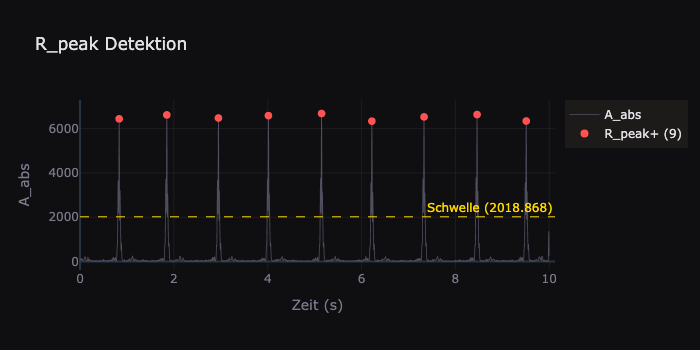

In [4]:
plot_r_peak_detection(df_analysis, r_peak_times, r_peak_values).show()


## 3. Ein Beat, aus der Nähe

`A_abs` verschluckt P und T neben der QRS-Spitze — der VCG-Betrag `r` (Abstand vom Ursprung im Frank-XYZ-Raum) zeigt alle drei Wellen auf vergleichbarer Skala, automatisch farbig nach Segment (P/QRS/ST/T).


df_markers:    13 Punkte   (full)
df_segments:    5 Segmente (full)


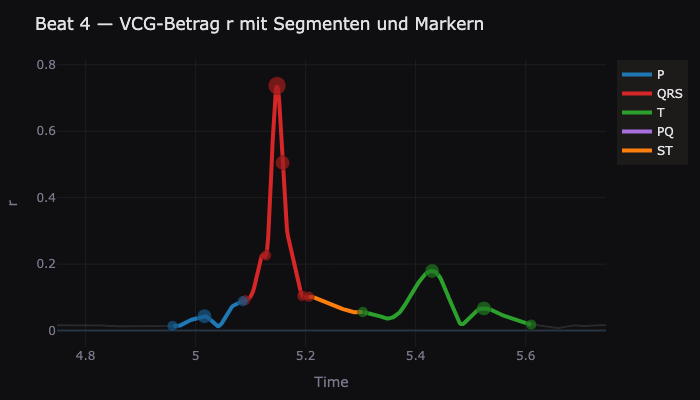

In [5]:
BEAT_ID = int(df_annotations["beat_id"].iloc[4])
df_markers, df_segments = build_plot_data(df_annotations, beat_id=BEAT_ID, mode="full")
beat_row = df_annotations[df_annotations["beat_id"] == BEAT_ID].iloc[0]
t_center = beat_row["t_R_peak+"]

plot_signal_segments_and_markers(
    df_analysis, signal_col="r",
    df_segments=df_segments, df_markers=df_markers,
    t_start=t_center - 0.4, t_end=t_center + 0.6,
    title=f"Beat {BEAT_ID} — VCG-Betrag r mit Segmenten und Markern",
).show()


## 4. Derselbe Beat, jetzt in 3D

Dieselben Marker, aber auf der tatsächlichen 3D-Trajektorie im Frank-XYZ-Raum — die "Loops", aus denen `vcgsuite.features.loop` seine Geometrie-Features (Fläche, Rundheit, Winkel, ...) berechnet.


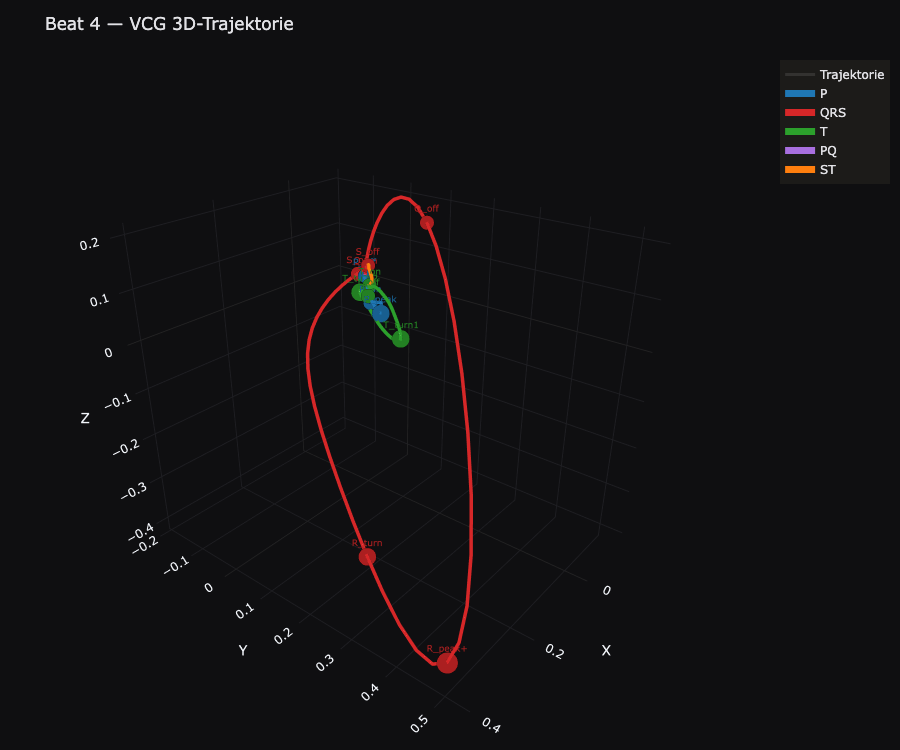

In [6]:
plot_vcg_3d(
    df_analysis, df_segments=df_segments, df_markers=df_markers,
    t_start=t_center - 0.4, t_end=t_center + 0.6,
    title=f"Beat {BEAT_ID} — VCG 3D-Trajektorie",
    camera_eye=dict(x=1.6, y=1.3, z=1.1), camera_up=dict(x=0, y=0, z=1),
).show()


## 5. Neun Herzschläge, ein Rhythmus

Alle neun Beats der Aufnahme übereinandergelegt (P-Beginn bis T-Ende, farblich nach Beat) — die Loops fast deckungsgleich. Genau diese Beat-zu-Beat-Konsistenz ist die Grundlage dafür, dass die Loop-Geometrie überhaupt als stabiles Merkmal taugt.


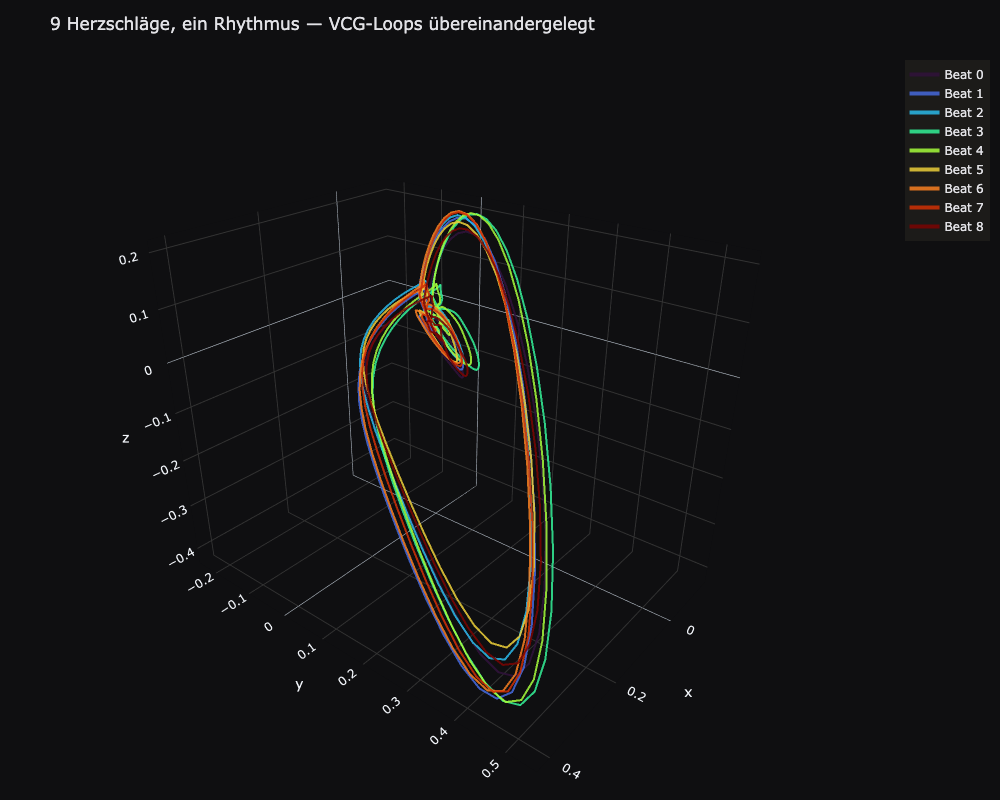

In [7]:
import plotly.graph_objects as go
import plotly.express as px

colors = px.colors.sample_colorscale("turbo", [i / (len(df_annotations) - 1) for i in range(len(df_annotations))])

fig = go.Figure()
for i, (_, beat) in enumerate(df_annotations.iterrows()):
    t0, t1 = beat["t_P_on"], beat["t_T_off"]
    if pd.isna(t0) or pd.isna(t1):
        continue
    seg = select_time_window(df_analysis, float(t0), float(t1), "Time")
    fig.add_trace(go.Scatter3d(
        x=seg["X"], y=seg["Y"], z=seg["Z"], mode="lines",
        line=dict(color=colors[i], width=4),
        name=f"Beat {int(beat['beat_id'])}", opacity=0.85,
    ))

fig.update_layout(
    template="plotly_dark", paper_bgcolor="#0f0f11",
    height=800, width=1000, margin=dict(l=10, r=10, t=60, b=10),
    title=dict(text="9 Herzschläge, ein Rhythmus — VCG-Loops übereinandergelegt", font=dict(color="#e2e2e6")),
    legend=dict(bgcolor="#1c1b19", font=dict(color="#e2e2e6")),
    scene=dict(
        xaxis=dict(backgroundcolor="#0f0f11", gridcolor="#333"),
        yaxis=dict(backgroundcolor="#0f0f11", gridcolor="#333"),
        zaxis=dict(backgroundcolor="#0f0f11", gridcolor="#333"),
        camera=dict(eye=dict(x=1.6, y=1.3, z=1.1), up=dict(x=0, y=0, z=1)),
        aspectmode="data",
    ),
)
fig.show()


## 6. Bonus: HRV auf einen Blick

Kubios-Style ANS-Balance aus den neun RR-Intervallen. **Nur zur Illustration** — 8.7 s / 9 Beats sind für eine echte HRV-Analyse viel zu kurz (Kubios & Co. empfehlen mehrere Minuten); für belastbare Kennwerte braucht es eine längere Aufnahme.


df_rr bereit
   Beats:       9
   Dauer:       8.7 s  (0.1 min)
   ∅ RR:        1077 ms  (∅ HR = 56 bpm)
   ∅ Rpeak_ca:  2.2083  (NaN: 0)
   ∅ Rpeak_r:   0.7061  (NaN: 0)
   t-Bereich:   [0.83, 9.51] s


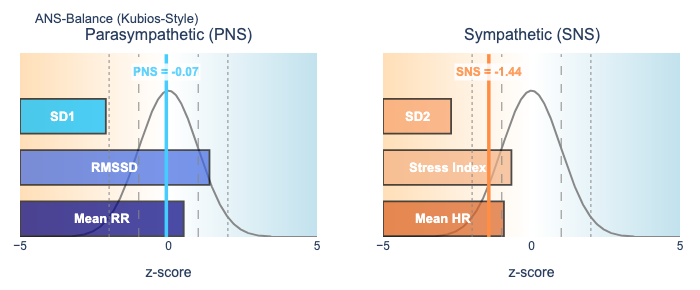

In [8]:
df_r = ecg.compute_beat_rotation(df_annotations, df_analysis)
df_rr = build_rr_dataframe(df_r)
hrv = compute_hrv_full(df_rr["RR_interval"].to_numpy())

plot_kubios_ans_balance(hrv).show()


---

**Weiter geht's:**
[`01_load_filter_annotate_visualize.ipynb`](01_load_filter_annotate_visualize.ipynb) und
[`02_feature_extraction.ipynb`](02_feature_extraction.ipynb) zeigen denselben Ablauf ausführlicher (eigene Aufnahme statt LUDB-Beispiel, alle Loop-Features, HRV, EDR).
Für die Validierung gegen die volle LUDB-Datenbank (200 Records) siehe
[`../../notebooks/ludb_validation.ipynb`](../../notebooks/ludb_validation.ipynb).
